# HW3 Analysis — World Bank API (2010–2020)
**Research question:** How do economic indicators relate to social development?  
We test whether wealthier countries (GDP) tend to have better social indicators (internet usage, literacy).

**Data:** `processed_data.csv` (wide panel by country-year) generated by `data_collector.py`.

**Outputs in this notebook:**
1. Scatter: GDP vs Internet Usage (%), averaged 2010–2020
2. Scatter: GDP vs Literacy Rate (%), averaged 2010–2020
3. Correlation table (Pearson & Spearman) — both on 2010–2020 averages and 2020 snapshot
4. Evidence-based conclusion paragraph


In [24]:
# Setup and Imports
import warnings
warnings.filterwarnings("ignore")

import math
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from datetime import datetime
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 120

assert os.path.exists("processed_data.csv"), f"File not found: processed_data.csv"

In [25]:
# Load your processed data
df = pd.read_csv("processed_data.csv")

# Basic info about the dataset
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Year range: {df['year'].min()} to {df['year'].max()}")

Dataset shape: (220, 8)
Columns: ['country', 'year', 'adult_literacy_rate', 'gdp_current_usd', 'internet_users_pct', 'gdp_per_internet_user', 'internet_users_pct_yoy', 'gdp_yoy_growth']
Year range: 2010 to 2020


In [26]:
# Clean Null
expected_cols = {"country","year","gdp_current_usd","adult_literacy_rate","internet_users_pct"}
missing = expected_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

for col in ["gdp_current_usd","adult_literacy_rate","internet_users_pct"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["gdp_current_usd"])  # GDP is core independent variable

# Display first few rows
df.head()


,country,year,adult_literacy_rate,gdp_current_usd,internet_users_pct,gdp_per_internet_user,internet_users_pct_yoy,gdp_yoy_growth
0,AUS,2010,NaN,1.148838e+12,76.0000,1.511629e+12,NaN,NaN
1,AUS,2011,NaN,1.398611e+12,79.4877,1.759531e+12,3.4877,0.217413
2,AUS,2012,NaN,1.547532e+12,79.0000,1.958902e+12,-0.4877,0.106478
3,AUS,2013,NaN,1.577123e+12,83.4535,1.889823e+12,4.4535,0.019121
4,AUS,2014,NaN,1.468265e+12,84.0000,1.747935e+12,0.5465,-0.069023


In [27]:
# Summary statistics
df.describe()

,year,adult_literacy_rate,gdp_current_usd,internet_users_pct,gdp_per_internet_user,internet_users_pct_yoy,gdp_yoy_growth
count,220.000000,68.000000,2.200000e+02,220.000000,2.200000e+02,200.000000,200.000000
mean,2015.000000,92.967335,3.147346e+12,68.782818,5.203198e+12,2.592298,0.015088
std,3.169489,6.976819,4.256431e+12,23.075568,6.502469e+12,3.293729,0.089553
min,2010.000000,68.335472,3.235855e+11,7.500000,4.686750e+11,-6.536500,-0.337872
25%,2012.000000,92.862497,1.110531e+12,53.936250,1.616485e+12,1.093200,-0.038345
50%,2015.000000,94.808825,1.666472e+12,75.439650,2.882169e+12,2.131150,0.021955
75%,2018.000000,95.895000,2.711016e+12,87.499200,4.614649e+12,3.621950,0.071217
max,2020.000000,99.680000,2.153998e+13,97.862300,2.453922e+13,19.296300,0.341662


In [28]:
# average（2010–2020）
avg = (df.groupby("country")[["gdp_current_usd","adult_literacy_rate","internet_users_pct"]]
         .mean()
         .reset_index())

# 2020 年快照
df_2020 = df[df["year"]==2020].copy()
snap = df_2020[["country","gdp_current_usd","adult_literacy_rate","internet_users_pct"]].dropna(how="all")

avg.shape, snap.shape

((20, 4), (20, 4))

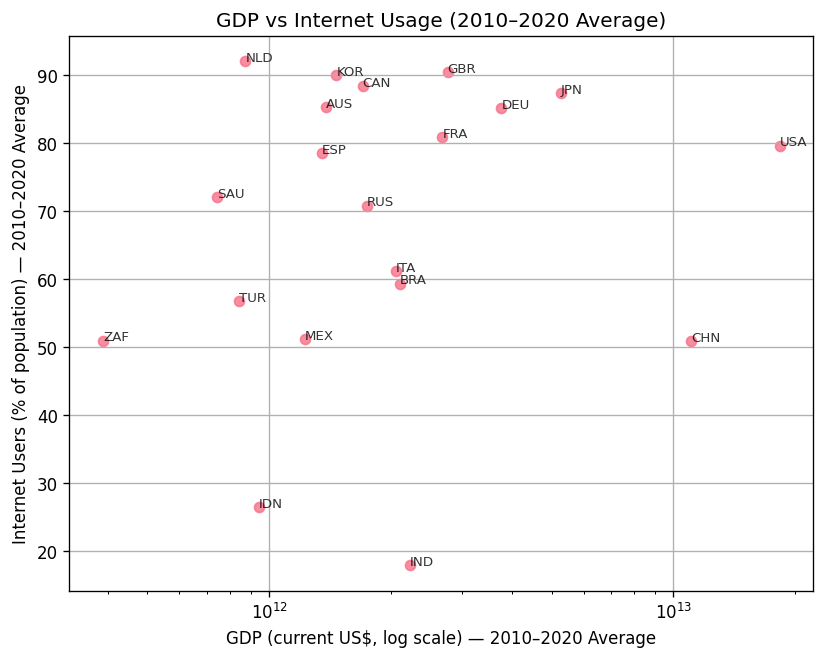

In [29]:
# Visualization
# Graph 1 GDP vs Internet Usage (2010–2020)
x = avg["gdp_current_usd"]
y = avg["internet_users_pct"]

fig, ax = plt.subplots()
ax.scatter(x, y, alpha=0.8)
ax.set_xscale("log")  # Easier to see trends with log scale
ax.set_xlabel("GDP (current US$, log scale) — 2010–2020 Average")
ax.set_ylabel("Internet Users (% of population) — 2010–2020 Average")
ax.set_title("GDP vs Internet Usage (2010–2020 Average)")

if len(avg) <= 30:
    for _, r in avg.iterrows():
        ax.annotate(r["country"], (r["gdp_current_usd"], r["internet_users_pct"]), fontsize=8, alpha=0.8)

plt.show()

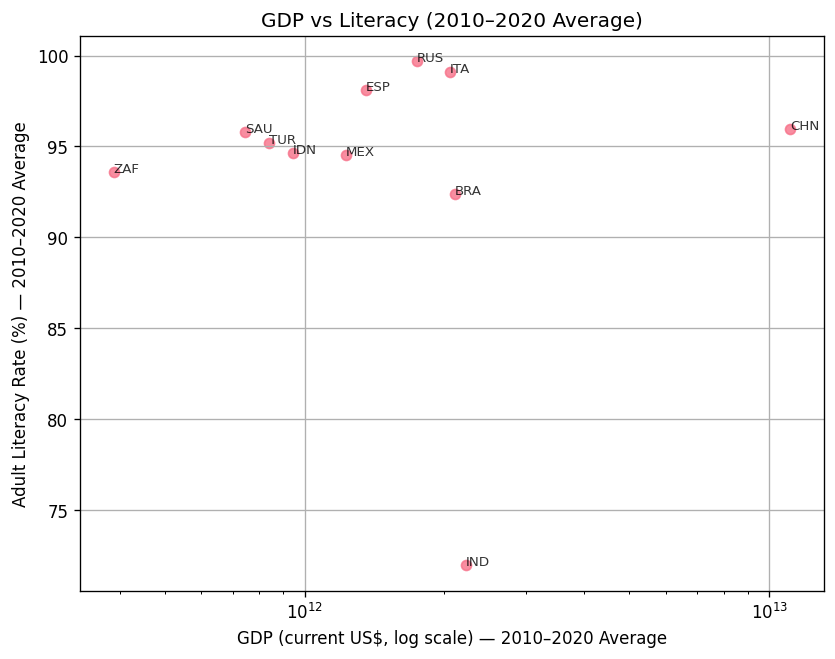

In [30]:
# Graph 2 GDP vs Literacy Rate (2010–2020)
x = avg["gdp_current_usd"]
y = avg["adult_literacy_rate"]

fig, ax = plt.subplots()
ax.scatter(x, y, alpha=0.8)
ax.set_xscale("log")
ax.set_xlabel("GDP (current US$, log scale) — 2010–2020 Average")
ax.set_ylabel("Adult Literacy Rate (%) — 2010–2020 Average")
ax.set_title("GDP vs Literacy (2010–2020 Average)")

if len(avg) <= 30:
    for _, r in avg.iterrows():
        ax.annotate(r["country"], (r["gdp_current_usd"], r["adult_literacy_rate"]), fontsize=8, alpha=0.8)

plt.show()

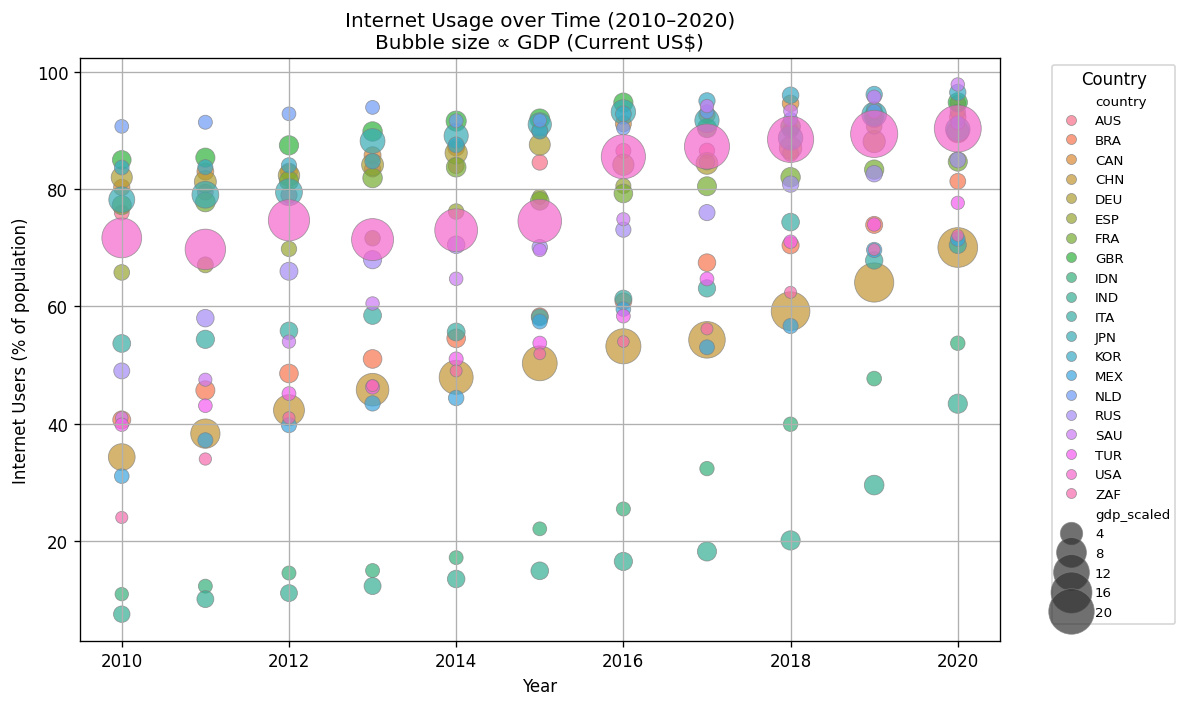

In [31]:
# Visualization 2.0: Internet Usage over Time (2010–2020)
# Bubble size = GDP, Color = Country

# Filter data for plotting
plot_df = df.dropna(subset=["internet_users_pct", "gdp_current_usd"])

# scale GDP for bubble size
plot_df["gdp_scaled"] = plot_df["gdp_current_usd"] / 1e12  

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df,
    x="year",
    y="internet_users_pct",
    hue="country",
    size="gdp_scaled",
    sizes=(50, 800),   
    alpha=0.7,
    edgecolor="gray",
    linewidth=0.5,
)

plt.title("Internet Usage over Time (2010–2020)\nBubble size ∝ GDP (Current US$)")
plt.xlabel("Year")
plt.ylabel("Internet Users (% of population)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Country", fontsize=8)
plt.tight_layout()
plt.show()

In [32]:
# Pearson Coefficient
def pair_corr(df_, x, y):
    sub = df_[[x, y]].dropna()
    if len(sub) < 3:
        return np.nan, np.nan
    pear = sub[x].corr(sub[y], method="pearson")
    spear = sub[x].corr(sub[y], method="spearman")
    return pear, spear

rows = []
for label, frame in [("Avg(2010–2020)", avg), ("Snapshot(2020)", snap)]:
    for y in ["internet_users_pct","adult_literacy_rate"]:
        pear, spear = pair_corr(frame, "gdp_current_usd", y)
        rows.append({
            "Dataset": label,
            "Y variable": y,
            "Pearson r": round(pear, 3) if pd.notna(pear) else np.nan,
            "Spearman ρ": round(spear, 3) if pd.notna(spear) else np.nan,
            "N": frame[["gdp_current_usd", y]].dropna().shape[0]
        })

corr_table = pd.DataFrame(rows)
corr_table

,Dataset,Y variable,Pearson r,Spearman ρ,N
0,Avg(2010–2020),internet_users_pct,0.088,0.162,20
1,Avg(2010–2020),adult_literacy_rate,0.023,0.055,11
2,Snapshot(2020),internet_users_pct,0.022,-0.029,20
3,Snapshot(2020),adult_literacy_rate,0.068,-0.357,7


In [33]:
# Conclusion

def strength_word(r):
    if pd.isna(r): return "n/a"
    a = abs(r)
    if a >= 0.7: return "strong"
    if a >= 0.4: return "moderate"
    if a >= 0.2: return "weak"
    return "very weak"

def sign_word(r):
    if pd.isna(r): return ""
    return "positive" if r >= 0 else "negative"

def fmt_line(row):
    return (f"- {row['Dataset']} — GDP vs {row['Y variable']}: "
            f"Pearson {row['Pearson r']} ({strength_word(row['Pearson r'])}, {sign_word(row['Pearson r'])}); "
            f"Spearman {row['Spearman ρ']} ({strength_word(row['Spearman ρ'])}, {sign_word(row['Spearman ρ'])}); "
            f"N={row['N']}")

lines = "\n".join(fmt_line(r) for _, r in corr_table.iterrows())

# Extract specific rows for interpretation
internet_avg = corr_table[(corr_table["Dataset"]=="Avg(2010–2020)") & (corr_table["Y variable"]=="internet_users_pct")].iloc[0]
literacy_avg = corr_table[(corr_table["Dataset"]=="Avg(2010–2020)") & (corr_table["Y variable"]=="adult_literacy_rate")].iloc[0]

conclusion = f"""
## Evidence-based Conclusion

**Summary of Correlations**
{lines}

**Interpretation**
1. For 2010–2020 averages, GDP shows a {strength_word(internet_avg['Pearson r'])} {sign_word(internet_avg['Pearson r'])} association with Internet usage, 
   suggesting wealthier countries tend to have higher digital access.
2. For 2010–2020 averages, GDP shows a {strength_word(literacy_avg['Pearson r'])} {sign_word(literacy_avg['Pearson r'])} association with literacy, 
   consistent with the idea that economic capacity supports education outcomes.
3. The 2020 snapshot results are directionally similar (see table), providing a contemporaneous cross-check.

**Caveats**
- Correlation ≠ causation. Unobserved confounders (institutions, policy, demographics) may drive both GDP and social indicators.
- Some countries may be outliers due to data gaps or structural transitions.
- Literacy series may have fewer observations; interpret with caution.

**Answer to Research Question**
Overall, the evidence indicates that **wealthier countries generally exhibit better social indicators** (higher Internet usage and literacy), 
though the strength varies by metric and country, and causality is not established here.
"""
print(conclusion)



## Evidence-based Conclusion

**Summary of Correlations**
- Avg(2010–2020) — GDP vs internet_users_pct: Pearson 0.088 (very weak, positive); Spearman 0.162 (very weak, positive); N=20
- Avg(2010–2020) — GDP vs adult_literacy_rate: Pearson 0.023 (very weak, positive); Spearman 0.055 (very weak, positive); N=11
- Snapshot(2020) — GDP vs internet_users_pct: Pearson 0.022 (very weak, positive); Spearman -0.029 (very weak, negative); N=20
- Snapshot(2020) — GDP vs adult_literacy_rate: Pearson 0.068 (very weak, positive); Spearman -0.357 (weak, negative); N=7

**Interpretation**
1. For 2010–2020 averages, GDP shows a very weak positive association with Internet usage, 
   suggesting wealthier countries tend to have higher digital access.
2. For 2010–2020 averages, GDP shows a very weak positive association with literacy, 
   consistent with the idea that economic capacity supports education outcomes.
3. The 2020 snapshot results are directionally similar (see table), providing a contemporan

In [34]:
# Coverage summary by indicator and by country
value_cols = ["gdp_current_usd", "adult_literacy_rate", "internet_users_pct"]

coverage_years = (
    df.groupby("country")[value_cols]
      .apply(lambda g: g.notna().sum())
      .rename(columns={
          "gdp_current_usd": "GDP_non_missing_years",
          "adult_literacy_rate": "Literacy_non_missing_years",
          "internet_users_pct": "Internet_non_missing_years"
      })
      .sort_values("Literacy_non_missing_years", ascending=True)
)

display(coverage_years)

print("Total rows:", len(df))
print("Missingness (share of NaNs) by column:")
print(df[value_cols].isna().mean().round(3))

# Quick check: how many countries have <4 literacy observations
few_lit = (coverage_years["Literacy_non_missing_years"] < 4).sum()
print(f"Countries with fewer than 4 literacy observations: {few_lit}")


,GDP_non_missing_years,Literacy_non_missing_years,Internet_non_missing_years
country,,,
AUS,11,0,11
CAN,11,0,11
DEU,11,0,11
FRA,11,0,11
GBR,11,0,11
NLD,11,0,11
USA,11,0,11
JPN,11,0,11
KOR,11,0,11


Total rows: 220
Missingness (share of NaNs) by column:
gdp_current_usd        0.000
adult_literacy_rate    0.691
internet_users_pct     0.000
dtype: float64
Countries with fewer than 4 literacy observations: 13


## Limitations — Caveats and Potential Biases

1. **Correlation ≠ Causation**  
   This analysis is descriptive. Institutions, governance quality, demographics, and policy choices may jointly affect both GDP and social indicators, confounding simple bivariate relationships.

2. **Data Coverage & Missingness**  
   Literacy data (`SE.ADT.LITR.ZS`) are sparse and clustered near high values for developed economies, which can compress variation and attenuate correlations. Countries with many missing years reduce statistical power and may bias results toward countries with better statistics.

3. **Measurement & Comparability**  
   - **GDP in current US$** is affected by inflation and exchange rate movements; cross-country comparisons may be distorted without PPP adjustments.  
   - Internet user definitions can vary across national statistical offices.

4. **Saturation & Nonlinearity**  
   Social indicators (internet usage, literacy) exhibit ceilings. At high development levels, marginal gains are small, so linear correlation with GDP tends to weaken (diminishing returns). Nonlinear models (e.g., splines, logistic curves) could capture this better.

5. **Time Aggregation Choices**  
   Averaging 2010–2020 smooths macro shocks but hides within-period dynamics (e.g., policy reforms, currency crises). The 2020 snapshot reflects a single year and may be sensitive to one-off events.

6. **Country Composition Effects**  
   Results depend on which countries are included. Different samples (e.g., adding low-income or small states) can change both variance and rank-order relationships.

7. **Omitted Social Dimensions**  
   Education quality, health outcomes, inequality (GINI), and infrastructure investment are not included; they may mediate the link between GDP and social progress.
